Part C: Image Data
 
**Dataset:** Chest X-Ray Images (Pneumonia)  
**Objective:** Data acquisition, cleaning (metadata anonymization), preprocessing and analysis on medical image data

In [1]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

/home/sambhav/miniconda3/envs/mlenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.29G/2.29G [02:33<00:00, 16.1MB/s]

Extracting files...


Path to dataset files: /home/sambhav/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from PIL.ExifTags import TAGS
import shutil

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [16]:
# Find the chest_xray directory
base_path = os.path.join(path, 'chest_xray')
if not os.path.exists(base_path):
    # Some versions nest differently
    base_path = os.path.join(path, '2', 'chest_xray')
if not os.path.exists(base_path):
    base_path = path

print(f"Base path: {base_path}")
print(f"Contents: {os.listdir(base_path)}")

Base path: /home/sambhav/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray
Contents: ['__MACOSX', 'chest_xray', 'test', 'train', 'val', 'anonymized_sample']


In [17]:
# Count images per split and class
data_info = {}
for split in ['train', 'val', 'test']:
    split_path = os.path.join(base_path, split)
    if os.path.exists(split_path):
        for cls in sorted(os.listdir(split_path)):
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                count = len([f for f in os.listdir(cls_path) if f.endswith(('.jpeg', '.jpg', '.png'))])
                data_info[f'{split}/{cls}'] = count
                print(f"{split}/{cls}: {count} images")

print(f"\nTotal images: {sum(data_info.values())}")

train/NORMAL: 1341 images
train/PNEUMONIA: 3875 images
val/NORMAL: 8 images
val/PNEUMONIA: 8 images
test/NORMAL: 234 images
test/PNEUMONIA: 390 images

Total images: 5856


In [18]:
# Check image properties
sample_img_path = None
for split in ['train', 'val', 'test']:
    split_path = os.path.join(base_path, split)
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            for f in os.listdir(cls_path):
                if f.endswith(('.jpeg', '.jpg', '.png')):
                    sample_img_path = os.path.join(cls_path, f)
                    break
        if sample_img_path:
            break
    if sample_img_path:
        break

img = Image.open(sample_img_path)
print(f"Sample image: {sample_img_path}")
print(f"Size: {img.size}")
print(f"Mode: {img.mode}")
print(f"Format: {img.format}")
print(f"Info keys: {list(img.info.keys())}")

Sample image: /home/sambhav/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/train/NORMAL/IM-0115-0001.jpeg
Size: (2090, 1858)
Mode: L
Format: JPEG
Info keys: ['jfif', 'jfif_version', 'jfif_unit', 'jfif_density', 'exif', 'photoshop', 'icc_profile', 'dpi']


In [19]:
# Check EXIF data in sample images
print("Checking EXIF data in sample images...")
print("=" * 50)

exif_count = 0
total_checked = 0

for split in ['train', 'val', 'test']:
    split_path = os.path.join(base_path, split)
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue
        for f in os.listdir(cls_path)[:10]:  # Check first 10 per class
            if f.endswith(('.jpeg', '.jpg', '.png')):
                img = Image.open(os.path.join(cls_path, f))
                exif = img.getexif() if hasattr(img, 'getexif') else {}
                total_checked += 1
                if exif:
                    exif_count += 1
                    if exif_count <= 3:
                        print(f"\n{split}/{cls}/{f} - EXIF found ({len(exif)} tags):")
                        for tag_id, value in list(exif.items())[:5]:
                            tag_name = TAGS.get(tag_id, tag_id)
                            print(f"  {tag_name}: {str(value)[:50]}")

print(f"\nSummary: {exif_count}/{total_checked} images have EXIF data")

Checking EXIF data in sample images...

train/NORMAL/IM-0115-0001.jpeg - EXIF found (1 tags):
  ExifOffset: 26

train/NORMAL/IM-0117-0001.jpeg - EXIF found (1 tags):
  ExifOffset: 26

train/NORMAL/IM-0119-0001.jpeg - EXIF found (1 tags):
  ExifOffset: 26

Summary: 18/56 images have EXIF data


In [20]:
def anonymize_image_metadata(input_path, output_path):
    """Remove all EXIF metadata from an image and save a clean copy."""
    img = Image.open(input_path)
    
    # Create a new image without metadata
    data = list(img.getdata())
    clean_img = Image.new(img.mode, img.size)
    clean_img.putdata(data)
    
    # Save without metadata
    clean_img.save(output_path, quality=95)
    return True

# Create anonymized copy of a small sample to demonstrate
anonymized_dir = os.path.join(base_path, 'anonymized_sample')
os.makedirs(anonymized_dir, exist_ok=True)

# Anonymize 3 sample images
samples_anonymized = 0
for split in ['train']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        cls_path = os.path.join(base_path, split, cls)
        for f in os.listdir(cls_path):
            if f.endswith(('.jpeg', '.jpg', '.png')) and samples_anonymized < 3:
                src = os.path.join(cls_path, f)
                dst = os.path.join(anonymized_dir, f'anon_{cls}_{f}')
                anonymize_image_metadata(src, dst)
                
                # Verify
                orig = Image.open(src)
                clean = Image.open(dst)
                orig_exif = len(orig.getexif()) if hasattr(orig, 'getexif') else 0
                clean_exif = len(clean.getexif()) if hasattr(clean, 'getexif') else 0
                print(f"Anonymized: {f}")
                print(f"  Original EXIF: {orig_exif} tags -> Clean EXIF: {clean_exif} tags")
                samples_anonymized += 1

print(f"\nAnonymization complete. {samples_anonymized} images processed.")

Anonymized: IM-0115-0001.jpeg
  Original EXIF: 1 tags -> Clean EXIF: 0 tags
Anonymized: IM-0117-0001.jpeg
  Original EXIF: 1 tags -> Clean EXIF: 0 tags
Anonymized: IM-0119-0001.jpeg
  Original EXIF: 1 tags -> Clean EXIF: 0 tags

Anonymization complete. 3 images processed.


### Class Distribution

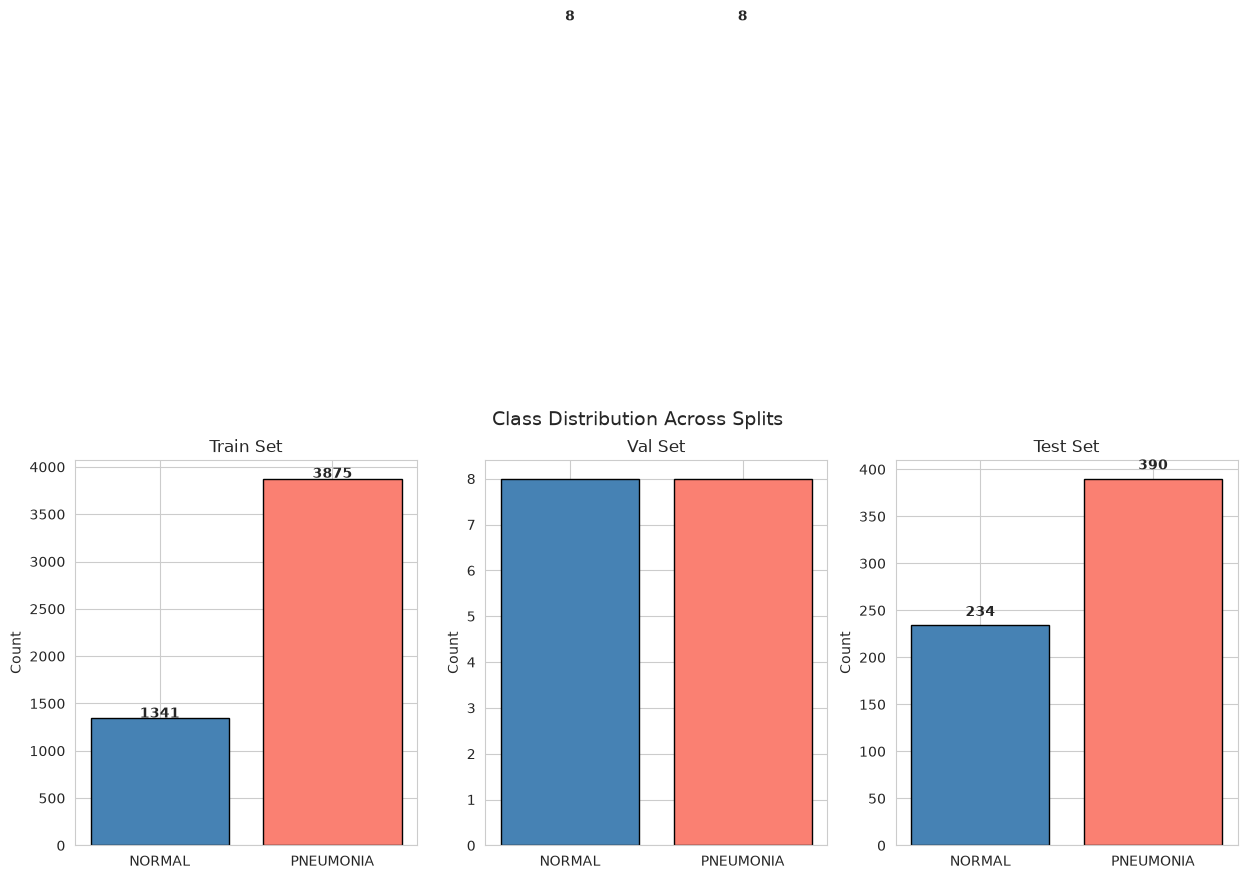

In [28]:
# Prepare data for plotting
splits = ['train', 'val', 'test']
classes = ['NORMAL', 'PNEUMONIA']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, split in enumerate(splits):
    counts = []
    for cls in classes:
        cls_path = os.path.join(base_path, split, cls)
        if os.path.exists(cls_path):
            count = len([f for f in os.listdir(cls_path) if f.endswith(('.jpeg', '.jpg', '.png'))])
        else:
            count = 0
        counts.append(count)
    
    axes[i].bar(classes, counts, color=['steelblue', 'salmon'], edgecolor='black')
    axes[i].set_title(f'{split.capitalize()} Set')
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts):
        axes[i].text(j, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution Across Splits', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
# Imbalance ratio
train_normal = len([f for f in os.listdir(os.path.join(base_path, 'train', 'NORMAL')) if f.endswith(('.jpeg', '.jpg', '.png'))])
train_pneumonia = len([f for f in os.listdir(os.path.join(base_path, 'train', 'PNEUMONIA')) if f.endswith(('.jpeg', '.jpg', '.png'))])

print(f"Train set imbalance ratio: {train_pneumonia/train_normal:.2f}:1 (Pneumonia:Normal)")
print(f"This is a significant class imbalance that should be addressed.")

Train set imbalance ratio: 2.89:1 (Pneumonia:Normal)
This is a significant class imbalance that should be addressed.


### Image Dimensions Analysis

In [30]:
# Sample image dimensions from each split
widths = []
heights = []
modes = []

for split in ['train', 'val', 'test']:
    for cls in classes:
        cls_path = os.path.join(base_path, split, cls)
        if not os.path.exists(cls_path):
            continue
        files = [f for f in os.listdir(cls_path) if f.endswith(('.jpeg', '.jpg', '.png'))]
        for f in files[:50]:  # Sample 50 per class
            img = Image.open(os.path.join(cls_path, f))
            widths.append(img.size[0])
            heights.append(img.size[1])
            modes.append(img.mode)

print(f"Sampled {len(widths)} images")
print(f"Width  - min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height - min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"Modes: {set(modes)}")

Sampled 216 images
Width  - min: 502, max: 2752, mean: 1487
Height - min: 307, max: 2458, mean: 1130
Modes: {'L', 'RGB'}


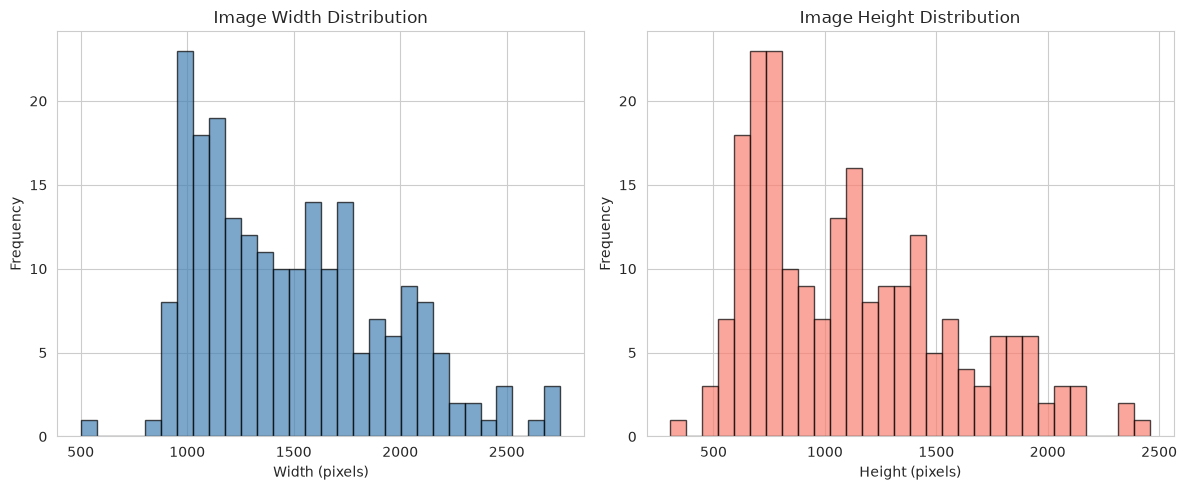

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(widths, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')

axes[1].hist(heights, bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Visualize Sample Images

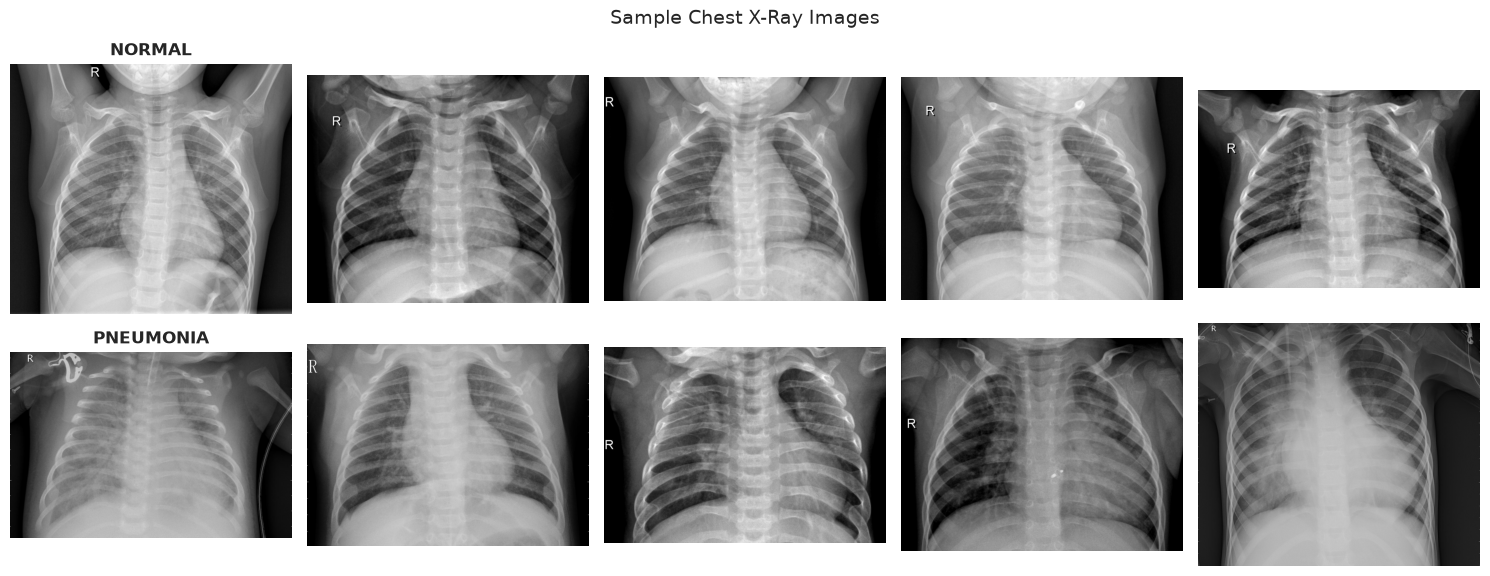

In [32]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, cls in enumerate(classes):
    cls_path = os.path.join(base_path, 'train', cls)
    files = [f for f in os.listdir(cls_path) if f.endswith(('.jpeg', '.jpg', '.png'))]
    for j in range(5):
        img = Image.open(os.path.join(cls_path, files[j]))
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(f'{cls}', fontsize=12, fontweight='bold')

plt.suptitle('Sample Chest X-Ray Images', fontsize=14)
plt.tight_layout()
plt.show()

### Pixel Intensity Distribution

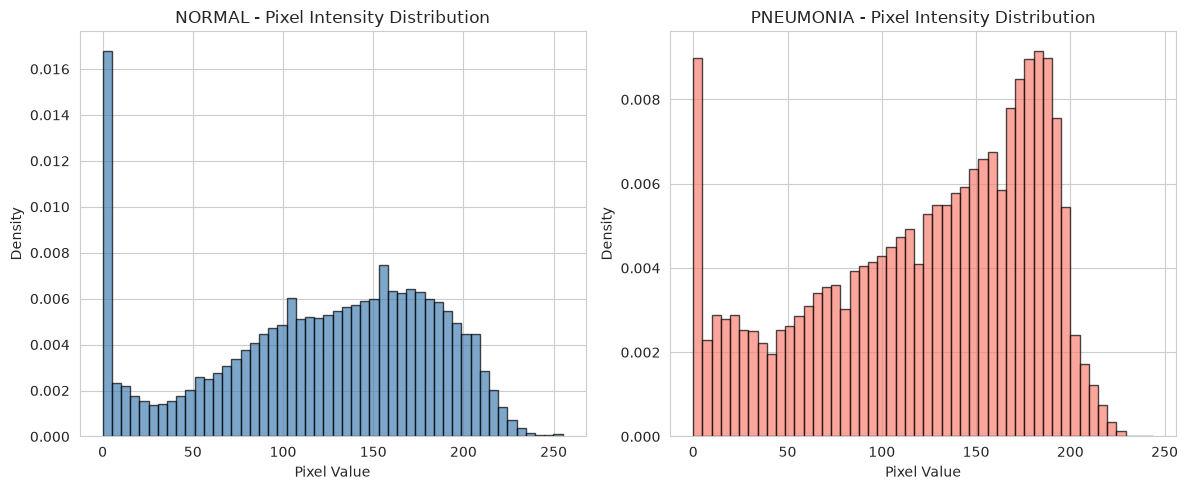

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
thumb_size = (64, 64)  # downscale to keep memory & compute small

for i, cls in enumerate(classes):
    cls_path = os.path.join(base_path, 'train', cls)
    files = [f for f in os.listdir(cls_path) if f.endswith(('.jpeg', '.jpg', '.png'))][:100]

    pixel_vals = []
    for f in files:
        img = Image.open(os.path.join(cls_path, f)).convert('L')  # grayscale
        img.thumbnail(thumb_size)                                   # resize in-place
        pixel_vals.append(np.array(img).flatten())

    pixel_vals = np.concatenate(pixel_vals)  # one big array instead of a Python list

    axes[i].hist(pixel_vals, bins=50, color=['steelblue', 'salmon'][i],
                 edgecolor='black', alpha=0.7, density=True)
    axes[i].set_title(f'{cls} - Pixel Intensity Distribution')
    axes[i].set_xlabel('Pixel Value')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image parameters
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Rescale pixel values to [0, 1]
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.1  # Use 10% of training data for validation
)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Load training data
train_generator = train_datagen.flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    color_mode='grayscale',
    seed=42
)

# Load validation data
val_generator = train_datagen.flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    color_mode='grayscale',
    seed=42
)

# Load test data
test_generator = test_datagen.flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

print(f"\nTrain samples: {train_generator.samples}")
print(f"Val samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"Class indices: {train_generator.class_indices}")

I0000 00:00:1789987487.050272   13037 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789987487.050442   13037 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789987487.077452   13037 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789987487.948823   13037 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Found 4695 images belonging to 2 classes.
Found 521 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Train samples: 4695
Val samples: 521
Test samples: 624
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [35]:
# Load a batch and inspect tensor shape
sample_batch, sample_labels = next(train_generator)

print(f"Batch shape: {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")
print(f"Dtype: {sample_batch.dtype}")
print(f"Pixel range: [{sample_batch.min():.3f}, {sample_batch.max():.3f}]")
print(f"Mean pixel value: {sample_batch.mean():.3f}")

Batch shape: (32, 150, 150, 1)
Labels shape: (32,)
Dtype: float32
Pixel range: [0.000, 1.000]
Mean pixel value: 0.497


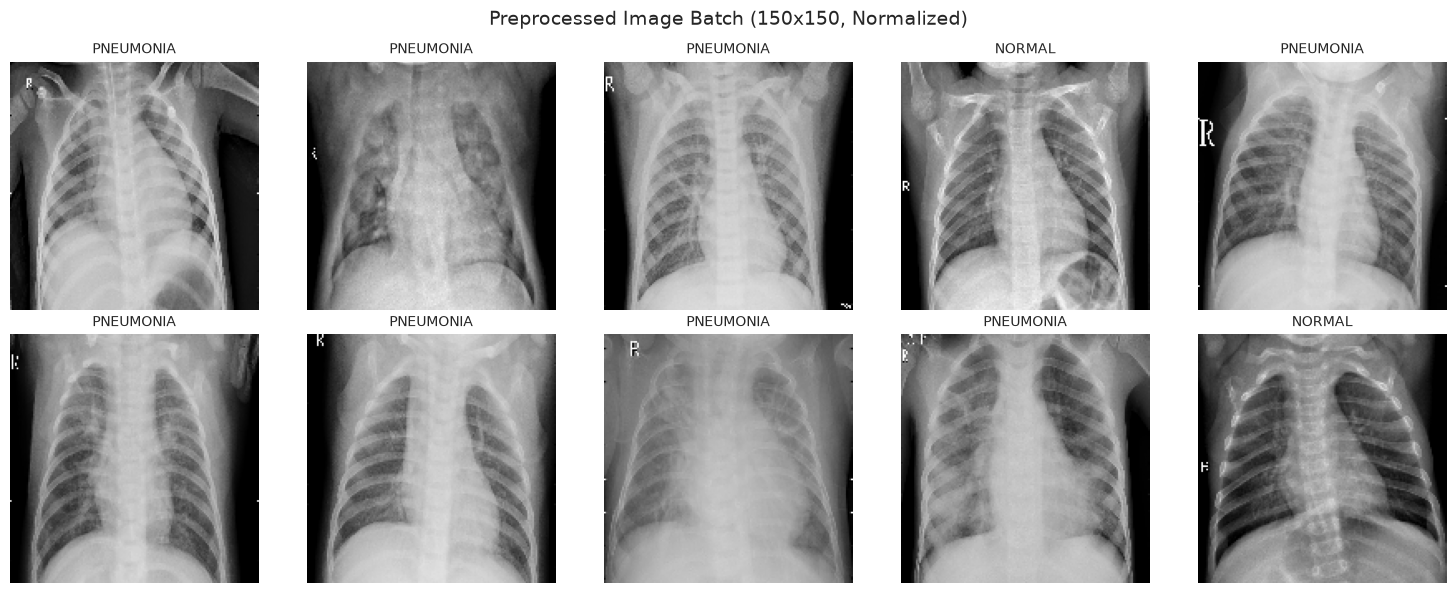

In [36]:
# Visualize preprocessed batch
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(sample_batch[i].squeeze(), cmap='gray')
    label = 'PNEUMONIA' if sample_labels[i] == 1 else 'NORMAL'
    ax.set_title(f'{label}', fontsize=10)
    ax.axis('off')

plt.suptitle('Preprocessed Image Batch (150x150, Normalized)', fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
# Compute per-class pixel statistics
class_stats = {}

for cls_name, cls_idx in train_generator.class_indices.items():
    cls_path = os.path.join(base_path, 'train', cls_name)
    files = [f for f in os.listdir(cls_path) if f.endswith(('.jpeg', '.jpg', '.png'))]
    
    means = []
    stds = []
    
    for f in files[:100]:  # Sample 100 images
        img = np.array(Image.open(os.path.join(cls_path, f)).resize((IMG_WIDTH, IMG_HEIGHT)))
        means.append(img.mean())
        stds.append(img.std())
    
    class_stats[cls_name] = {
        'mean_pixel': np.mean(means),
        'std_pixel': np.mean(stds),
        'mean_brightness': np.mean(means) / 255.0
    }
    print(f"{cls_name}:")
    print(f"  Mean pixel: {class_stats[cls_name]['mean_pixel']:.1f}")
    print(f"  Mean std: {class_stats[cls_name]['std_pixel']:.1f}")
    print(f"  Normalized brightness: {class_stats[cls_name]['mean_brightness']:.3f}")

NORMAL:
  Mean pixel: 119.6
  Mean std: 61.7
  Normalized brightness: 0.469
PNEUMONIA:
  Mean pixel: 122.3
  Mean std: 56.7
  Normalized brightness: 0.480


In [38]:
# Create augmented generator with clinically appropriate transforms
augmented_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=15,        # Small rotation (X-rays can be slightly tilted)
    width_shift_range=0.1,    # Small horizontal shift
    height_shift_range=0.1,   # Small vertical shift
    shear_range=0.1,          # Slight shearing
    zoom_range=0.1,           # Small zoom
    horizontal_flip=True,     # Horizontal flip is okay for chest X-rays
    fill_mode='nearest'
    # NO vertical flip - anatomically incorrect for chest X-rays
)

augmented_generator = augmented_datagen.flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1,
    class_mode='binary',
    color_mode='grayscale',
    classes=['NORMAL'],
    seed=42
)

print("Augmentation parameters:")
print(f"  Rotation: +/- 15 degrees")
print(f"  Shift: 10% width/height")
print(f"  Shear: 0.1")
print(f"  Zoom: 10%")
print(f"  Horizontal flip: Yes")
print(f"  Vertical flip: No (anatomically incorrect)")

Found 1341 images belonging to 1 classes.
Augmentation parameters:
  Rotation: +/- 15 degrees
  Shift: 10% width/height
  Shear: 0.1
  Zoom: 10%
  Horizontal flip: Yes
  Vertical flip: No (anatomically incorrect)


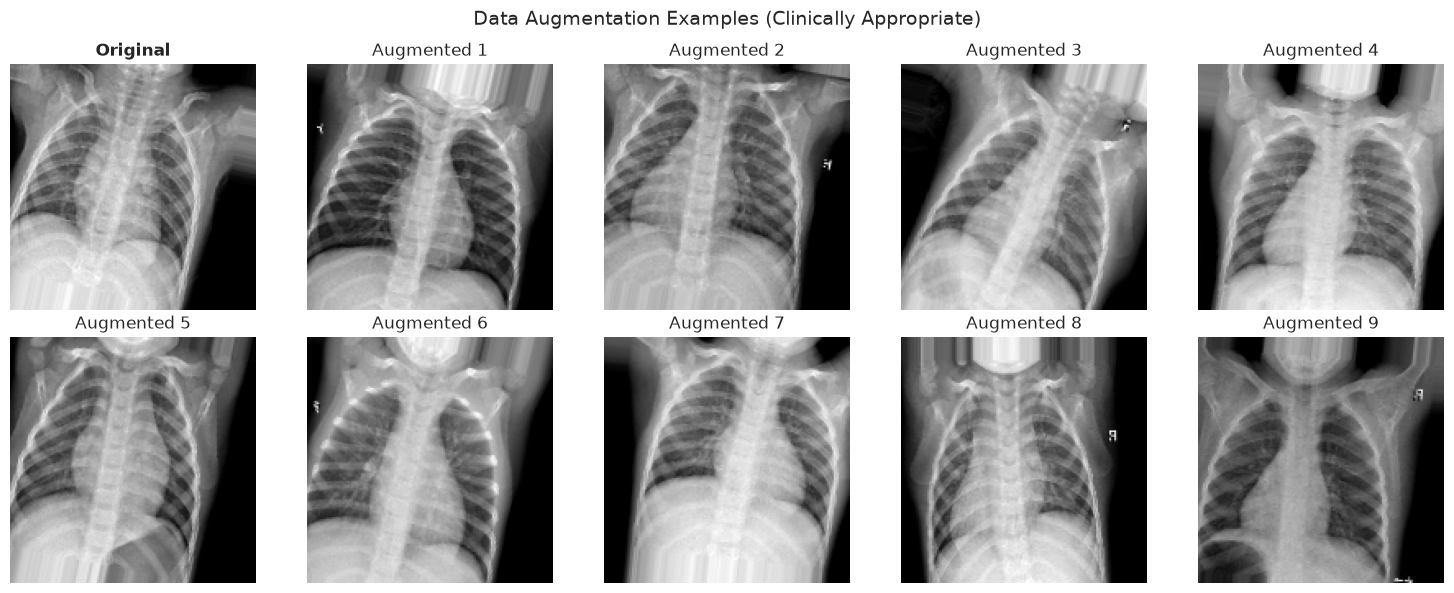

In [39]:
# Visualize augmented images
sample_img, _ = next(augmented_generator)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(sample_img.squeeze(), cmap='gray')
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

for i in range(1, 10):
    aug_img, _ = next(augmented_generator)
    ax = axes[i // 5, i % 5]
    ax.imshow(aug_img.squeeze(), cmap='gray')
    ax.set_title(f'Augmented {i}')
    ax.axis('off')

plt.suptitle('Data Augmentation Examples (Clinically Appropriate)', fontsize=14)
plt.tight_layout()
plt.show()

In [40]:
# Load a small batch as numpy arrays (model-ready format)
sample_generator = test_datagen.flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=100,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

X_sample, y_sample = next(sample_generator)

print(f"X tensor shape: {X_sample.shape}")
print(f"X dtype: {X_sample.dtype}")
print(f"X range: [{X_sample.min():.3f}, {X_sample.max():.3f}]")
print(f"\ny tensor shape: {y_sample.shape}")
print(f"y dtype: {y_sample.dtype}")
print(f"y unique values: {np.unique(y_sample)}")

Found 624 images belonging to 2 classes.
X tensor shape: (100, 150, 150, 1)
X dtype: float32
X range: [0.000, 1.000]

y tensor shape: (100,)
y dtype: float32
y unique values: [0.]


In [41]:
# Convert to float32 tensors
X_tensor = X_sample.astype(np.float32)
y_tensor = y_sample.astype(np.float32)

print(f"Final X tensor: {X_tensor.shape}, dtype={X_tensor.dtype}")
print(f"Final y tensor: {y_tensor.shape}, dtype={y_tensor.dtype}")

Final X tensor: (100, 150, 150, 1), dtype=float32
Final y tensor: (100,), dtype=float32
